In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_PATH = Path("/Users/federico/Desktop/progetto VIS/3. reparti AI&health/03_ai_medical_devices.csv")
df = pd.read_csv(DATA_PATH)

df = df.rename(columns=lambda c: c.strip())
df["Date of Final Decision"] = pd.to_datetime(df["Date of Final Decision"], errors="coerce")
df = df.dropna(subset=["Panel (Lead)", "Date of Final Decision"])

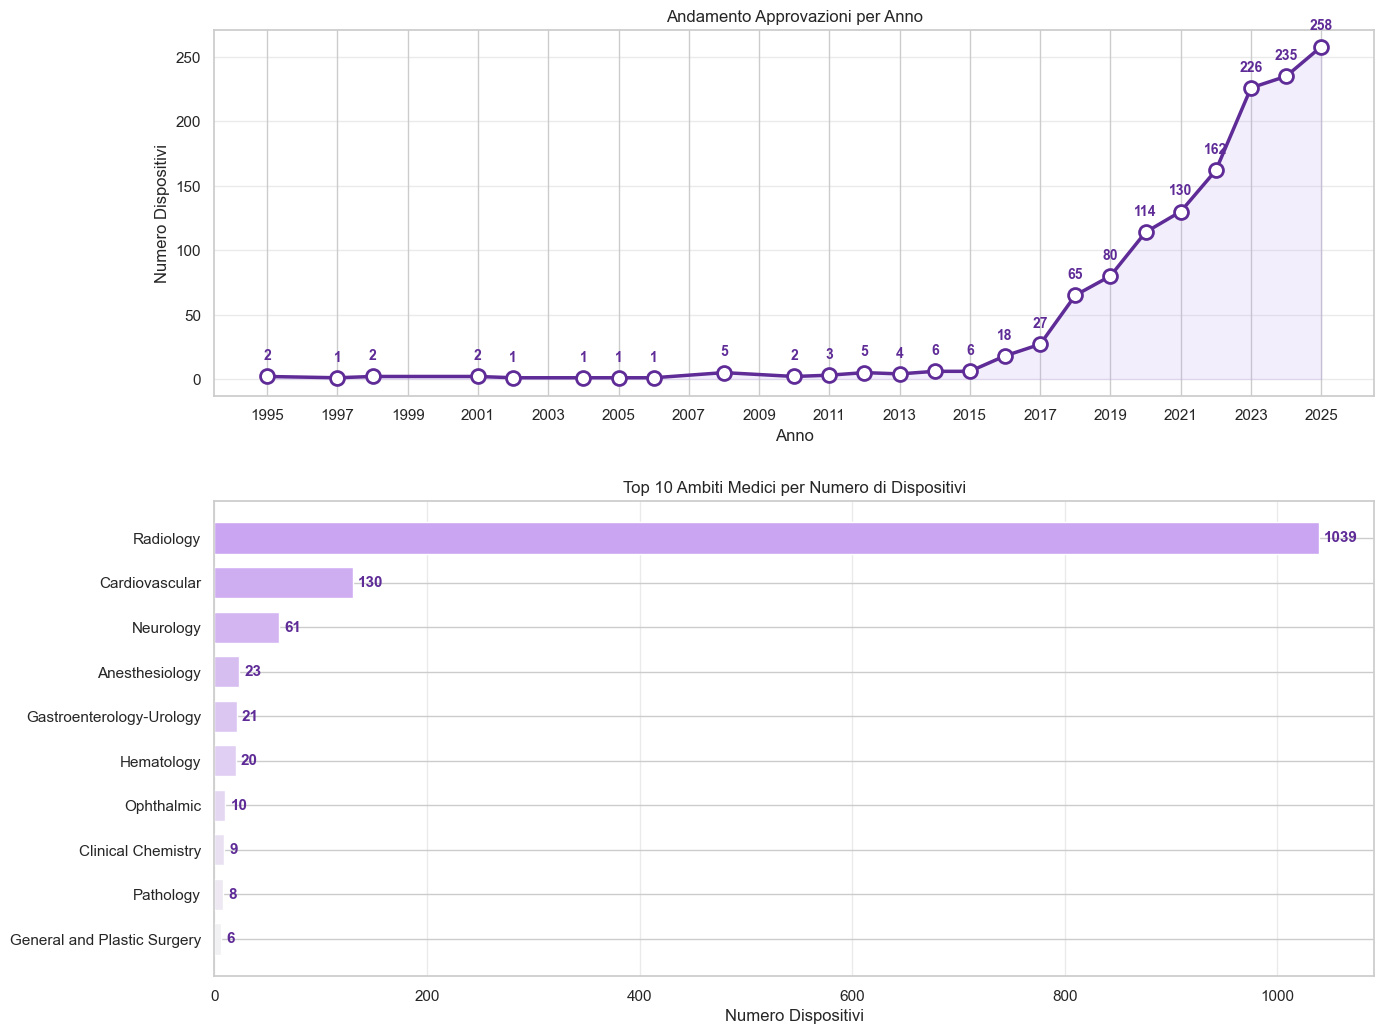

In [2]:
df["year"] = df["Date of Final Decision"].dt.year
by_year = df.groupby("year").size().reset_index(name="count")
panel_counts = df["Panel (Lead)"].value_counts().head(10)

fig, axes = plt.subplots(2, 1, figsize=(14, 11), gridspec_kw={'height_ratios': [1, 1.3]})
fig.suptitle("", fontsize=18, fontweight="bold", y=0.98, color="#3D1A6D")

axes[0].plot(by_year["year"], by_year["count"], marker="o", color="#5E2B97", lw=2.5, ms=10, mfc="white", mew=2)
axes[0].fill_between(by_year["year"], by_year["count"], alpha=0.15, color="#B493F0")
axes[0].set(title="Andamento Approvazioni per Anno", xlabel="Anno", ylabel="Numero Dispositivi")
axes[0].set_xticks(range(int(by_year["year"].min()), int(by_year["year"].max()) + 1, 2))
axes[0].grid(axis='y', alpha=0.4)
for x, y in zip(by_year["year"], by_year["count"]):
    axes[0].annotate(f"{y}", (x, y), textcoords="offset points", xytext=(0, 12), ha='center', fontsize=10, fontweight="bold", color="#5E2B97")

purple_grad = sns.light_palette("#caa5f1", n_colors=len(panel_counts), reverse=True)
bars = axes[1].barh(panel_counts.index, panel_counts.values, color=purple_grad, height=0.7, edgecolor="white")
axes[1].set(title="Top 10 Ambiti Medici per Numero di Dispositivi", xlabel="Numero Dispositivi")
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.4)
for bar, val in zip(bars, panel_counts.values):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2, f"{val}", va='center', fontsize=11, fontweight="bold", color="#5E2B97")

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.25)
plt.show()